# Telco Customer Churn & Retention Analysis
**Name:** Molebogeng Monama                                   
**Project:** Future Interns Data Science - Task 2  
**Goal:** To analyze customer behavior, identify churn drivers, and provide data-driven retention strategies.

### Key Business Questions Addressed:
1. Which customer segments are most likely to churn?
2. How long do customers typically stay active (Tenure)?
3. Why are customers leaving (Price Sensitivity)?

In [22]:
from google.colab import files
import pandas as pd

# This will trigger a popup to upload your 'WA_Fn-UseC_-Telco-Customer-Churn.csv'
uploaded = files.upload()

# Load the dataset into a Pandas DataFrame
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

# Display the first few rows to verify the upload
df.head()

Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn (2).csv


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [31]:
# 1. Convert TotalCharges to numeric (errors='coerce' turns blanks into NaN)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# 2. Check for nulls
null_count = df['TotalCharges'].isnull().sum()
print(f"Found {null_count} missing values in TotalCharges.")

# 3. Drop missing values
df.dropna(subset=['TotalCharges'], inplace=True)

# 4. Final Verification
print(f"Cleaning complete. {len(df)} rows remaining.")

Found 0 missing values in TotalCharges.
Cleaning complete. 7032 rows remaining.


In [32]:
# 1. Overall Churn Rate
total_customers = len(df)
churn_count = (df['Churn'] == 'Yes').sum()
overall_churn_rate = (churn_count / total_customers) * 100

print(f"--- GLOBAL METRICS ---")
print(f"Total Customer Base: {total_customers}")
print(f"Total Churned: {churn_count}")
print(f"Overall Churn Rate: {overall_churn_rate:.2f}%")

# 2. Churn by Contract (Specific Numbers)
contract_stats = df.groupby('Contract')['Churn'].value_counts(normalize=True).unstack() * 100
print(f"\n--- SEGMENT ANALYSIS (Churn Rate %) ---")
print(contract_stats['Yes'].round(2))

# 3. Average Monthly Charges
avg_charges_churn = df[df['Churn'] == 'Yes']['MonthlyCharges'].mean()
avg_charges_loyal = df[df['Churn'] == 'No']['MonthlyCharges'].mean()

print(f"\n--- PRICING INSIGHTS ---")
print(f"Average Bill (Churned): ${avg_charges_churn:.2f}")
print(f"Average Bill (Loyal):   ${avg_charges_loyal:.2f}")

--- GLOBAL METRICS ---
Total Customer Base: 7032
Total Churned: 1869
Overall Churn Rate: 26.58%

--- SEGMENT ANALYSIS (Churn Rate %) ---
Contract
Month-to-month    42.71
One year          11.28
Two year           2.85
Name: Yes, dtype: float64

--- PRICING INSIGHTS ---
Average Bill (Churned): $74.44
Average Bill (Loyal):   $61.31


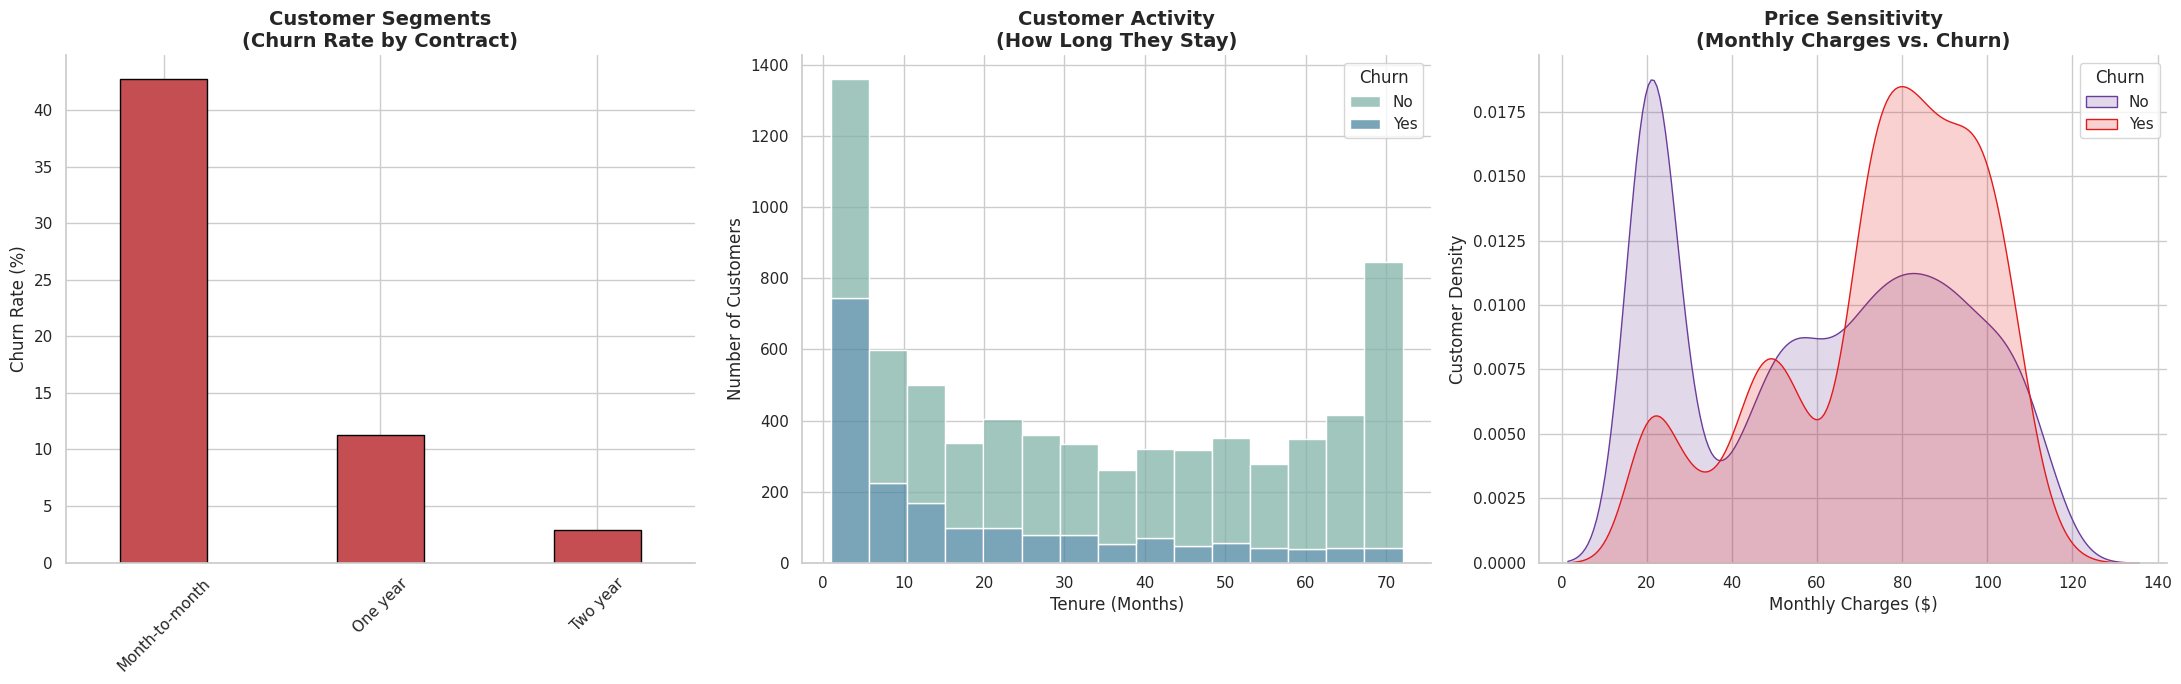

In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the dataset
# Replace with your actual file path
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

# 2. Data Cleaning: Convert TotalCharges to numeric (handles empty strings)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(subset=['TotalCharges'], inplace=True)

# 3. Calculate Churn Rate by Contract for Plot 1
contract_churn = df.groupby('Contract')['Churn'].value_counts(normalize=True).unstack()['Yes'] * 100
contract_order = ['Month-to-month', 'One year', 'Two year']
contract_churn = contract_churn.reindex(contract_order)

# 4. Set the visual theme
sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(1, 3, figsize=(22, 7))

# --- Plot 1: Customer Segments (Bar Chart) ---
contract_churn.plot(kind='bar', ax=axes[0], color='#C44E52', edgecolor='black', width=0.4)
axes[0].set_title('Customer Segments\n(Churn Rate by Contract)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Churn Rate (%)')
axes[0].set_xlabel('')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45)

# --- Plot 2: Customer Activity (Stacked Histogram) ---
sns.histplot(data=df, x='tenure', hue='Churn', multiple='stack',
             palette={'No': '#82B3A9', 'Yes': '#4E86A1'}, ax=axes[1], bins=15, edgecolor='white')
axes[1].set_title('Customer Activity\n(How Long They Stay)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Tenure (Months)')
axes[1].set_ylabel('Number of Customers')

# --- Plot 3: Price Sensitivity (KDE Plot) ---
sns.kdeplot(data=df[df['Churn'] == 'No'], x='MonthlyCharges', fill=True,
            color='#6A3D9A', label='No', ax=axes[2], alpha=0.2, linewidth=1)
sns.kdeplot(data=df[df['Churn'] == 'Yes'], x='MonthlyCharges', fill=True,
            color='#E31A1C', label='Yes', ax=axes[2], alpha=0.2, linewidth=1)
axes[2].set_title('Price Sensitivity\n(Monthly Charges vs. Churn)', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Monthly Charges ($)')
axes[2].set_ylabel('Customer Density')
axes[2].legend(title='Churn')

# Final formatting
sns.despine()
plt.tight_layout()
plt.show()

# Final Analysis & Strategic Recommendations

## 1. Target the "Month-to-Month" Risk
* **The Data:** Customers on Month-to-Month contracts have a churn rate of **42.7%**, which is nearly **15 times higher** than those on two-year contracts.
* **Recommendation:** Launch a "Long-Term Loyalty" campaign. Offer a significant discount (e.g., 15% off) or a free one-month service credit for customers who transition from monthly billing to an annual or two-year agreement.

## 2. Early Intervention (The 5-Month Window)
* **The Data:** The "Customer Activity" histogram shows a massive spike in churn within the **first 5 months** of tenure.
* **Recommendation:** Implement an automated "Customer Success" touchpoint sequence. Send a "check-in" email or offer a personalized tutorial session at the 2-month mark to ensure new users are finding value in their plans before they reach the critical 5-month exit point.

## 3. Pricing & Value Optimization
* **The Data:** The "Price Sensitivity" density plot proves that churn is highest for customers paying between **$70 and $100 per month**.
* **Recommendation:** Evaluate the features included in mid-to-high tier plans. Since customers at this price point are leaving most frequently, consider "bundling" additional perks (such as premium support or extra cloud storage) to increase the perceived value for this specific price bracket.